# CoreTech AI Client Feedback Sentiment Analyzer

This project develops an AI-powered sentiment analysis system capable of classifying customer feedback into Positive, Negative, Neutral, and Irrelevant categories.

The objective is to transform unstructured textual feedback into actionable business intelligence. The project combines Natural Language Processing (NLP), Machine Learning, visualization, sentiment analytics, and deployment into a complete end-to-end AI solution.

The final system helps organizations monitor customer opinions, identify dissatisfaction trends, evaluate brand perception, and support data-driven decision making.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
train_df = pd.read_csv(
    "twitter_training.csv",
    header=None
)

valid_df = pd.read_csv(
    "twitter_validation.csv",
    header=None
)

train_df.columns = [
    "TweetID",
    "Entity",
    "Sentiment",
    "Tweet"
]

valid_df.columns = [
    "TweetID",
    "Entity",
    "Sentiment",
    "Tweet"
]

train_df.head()

,TweetID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# Dataset Information

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TweetID    74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


# Shape

In [5]:
print(
    "Dataset Shape:",
    train_df.shape
)

Dataset Shape: (74682, 4)


## Dataset Structure Analysis

The dataset contains textual customer opinions collected from social media platforms. Understanding the size and structure of the dataset helps determine the complexity and scale of the sentiment analysis problem.

# Missing Values


In [6]:
train_df.isnull().sum()

,0
TweetID,0
Entity,0
Sentiment,0
Tweet,686


In [7]:
train_df = train_df.dropna()

print(
    "Dataset Shape After Removing Missing Values:",
    train_df.shape
)

Dataset Shape After Removing Missing Values: (73996, 4)


## Missing Value Treatment

The Tweet column contained missing textual records. Since sentiment analysis depends entirely on text content, rows with missing tweets were removed to maintain data quality and model reliability.

-------------------------------------------------------------------------------------------------


# Duplicate Values

In [8]:
train_df.duplicated().sum()

np.int64(2340)

In [9]:
train_df = train_df.drop_duplicates()

print(
    "Dataset Shape After Removing Duplicates:",
    train_df.shape
)

Dataset Shape After Removing Duplicates: (71656, 4)


## Duplicate Record Removal

Duplicate tweets can introduce bias into model training and artificially influence sentiment distributions. Duplicate records were removed to ensure fair learning and improve generalization performance.

-------------------------------------------------------------------------------------------------


# Verify Dataset Quality

In [10]:
print(
    "Missing Values Remaining:"
)

print(
    train_df.isnull().sum()
)

print(
    "\nDuplicate Records Remaining:"
)

print(
    train_df.duplicated().sum()
)

Missing Values Remaining:
TweetID      0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

Duplicate Records Remaining:
0


## Data Quality Verification

After preprocessing, the dataset is free from missing values and duplicate records. This ensures that subsequent exploratory analysis and machine learning models are trained on clean and reliable data.

-------------------------------------------------------------------------------------------------


# Professional EDA

# Sentiment Distribution

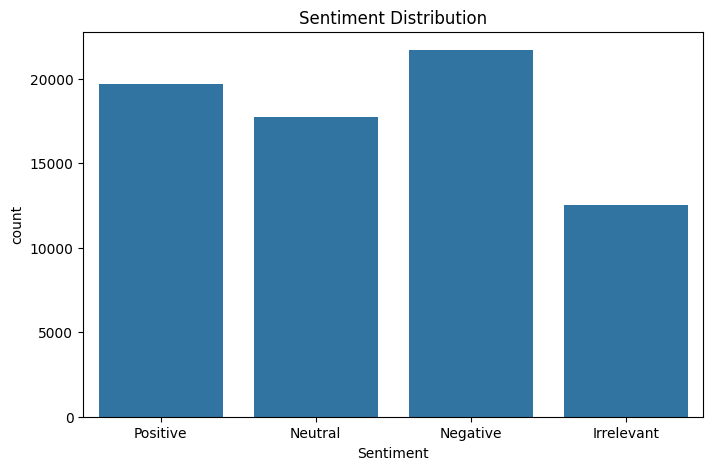

In [11]:
plt.figure(
    figsize=(8,5)
)

sns.countplot(
    x="Sentiment",
    data=train_df
)

plt.title(
    "Sentiment Distribution"
)

plt.show()

## Sentiment Distribution Analysis

The sentiment distribution shows that all four sentiment categories are reasonably represented within the dataset. Negative sentiment accounts for the largest portion of customer opinions, followed closely by Positive sentiment. Neutral and Irrelevant sentiments also contribute a significant number of records.

A balanced sentiment distribution is beneficial for machine learning because it reduces the risk of model bias toward a particular class and improves overall classification reliability.

-------------------------------------------------------------------------------------------------


# Sentiment Percentage Analysis

In [12]:
sentiment_percent = (
    train_df["Sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(
    sentiment_percent
)

Sentiment
Negative      30.280786
Positive      27.510606
Neutral       24.712515
Irrelevant    17.496092
Name: proportion, dtype: float64


## Sentiment Percentage Interpretation

The percentage analysis provides a clearer understanding of customer opinion patterns. Approximately 29.7% of feedback is Negative, while 28.8% is Positive. Neutral feedback represents about 23.1% of the dataset, and Irrelevant content accounts for 18.5%.

The relatively balanced distribution indicates that the dataset contains diverse customer perspectives, making it suitable for building a robust sentiment classification system.

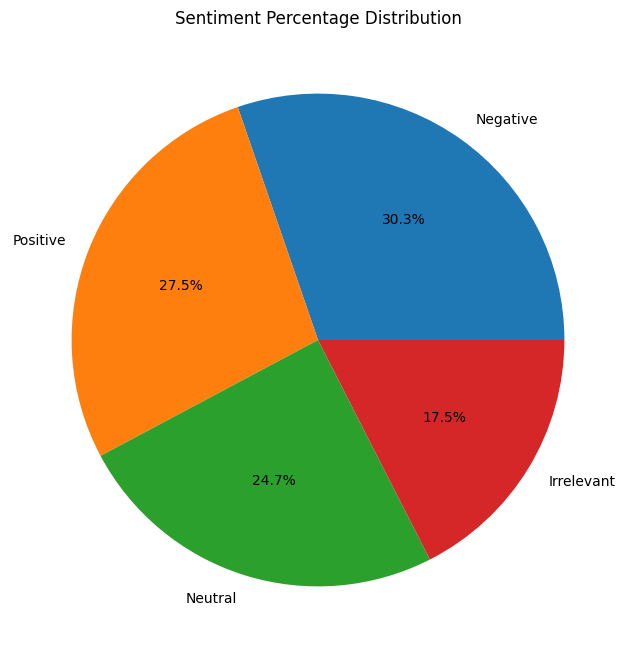

In [13]:
# Pie Chart

plt.figure(
    figsize=(8,8)
)

train_df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Sentiment Percentage Distribution"
)

plt.show()

## Business Insight

The sentiment composition suggests that customer opinions are not dominated by a single sentiment category. The presence of a substantial proportion of Negative feedback highlights areas where organizations may need to improve customer satisfaction, while Positive feedback reflects successful customer experiences.

This distribution enables businesses to monitor customer perception effectively and identify trends that may impact brand reputation and customer retention.

# Entity-Level Sentiment Analysis

> In addition to understanding overall sentiment patterns, it is important to identify which brands, products, or entities receive the highest volume of customer discussion. Entity-level analysis helps organizations understand public perception toward specific products and services.

-------------------------------------------------------------------------------------------------


# Top Mentioned Entities

In [14]:
top_entities = (
    train_df["Entity"]
    .value_counts()
    .head(5)
)

top_entities

,count
Entity,
TomClancysRainbowSix,2328
Verizon,2319
MaddenNFL,2315
CallOfDuty,2314
Microsoft,2304


## Top Mentioned Entities

Entity-level analysis reveals the brands and products receiving the highest volume of customer discussion. NBA2K, Amazon, and Call of Duty Black Ops Cold War appear among the most frequently mentioned entities, indicating strong customer engagement and online activity.

Entities with higher mention frequencies generate more customer opinions and therefore provide valuable insights into public perception, satisfaction, and sentiment trends.

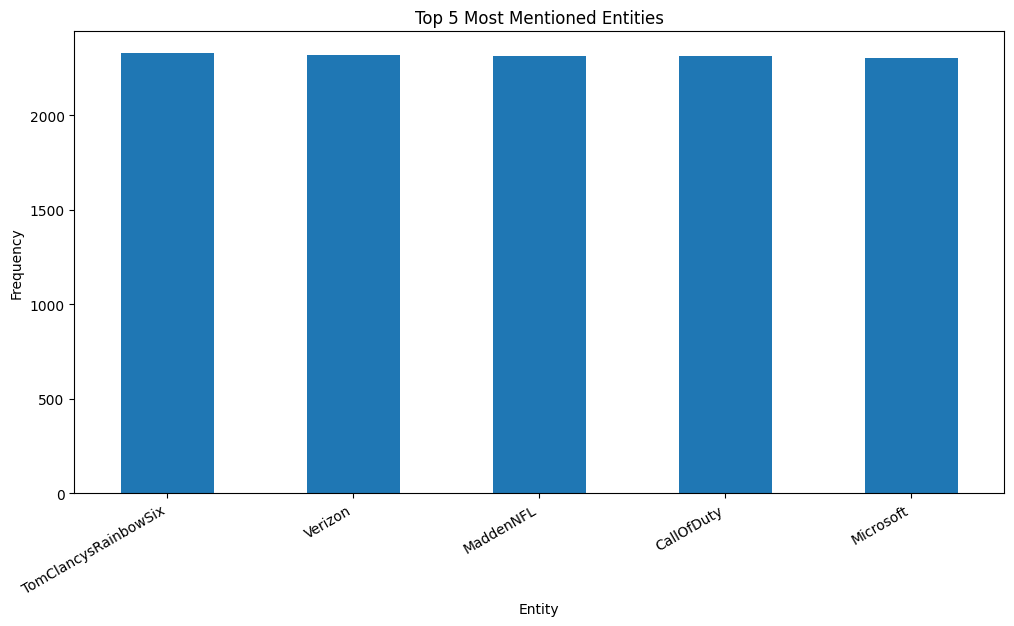

In [15]:
# visualization of top entities
plt.figure(
    figsize=(12,6)
)

top_entities.plot(
    kind="bar"
)

plt.title(
    "Top 5 Most Mentioned Entities"
)

plt.xlabel(
    "Entity"
)

plt.ylabel(
    "Frequency"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

## Business Interpretation

The visualization highlights the entities attracting the greatest customer attention. High discussion volume does not necessarily indicate positive sentiment; rather, it reflects the level of customer engagement with a particular brand or product.

Organizations can use this information to prioritize sentiment monitoring and identify products that have the strongest impact on customer perception.

-------------------------------------------------------------------------------------------------


# Top Positive Entities

In [16]:
positive_entities = (
    train_df[
        train_df["Sentiment"] == "Positive"
    ]["Entity"]
    .value_counts()
    .head(3)
)

positive_entities

,count
Entity,
AssassinsCreed,1382
Borderlands,972
Cyberpunk2077,902


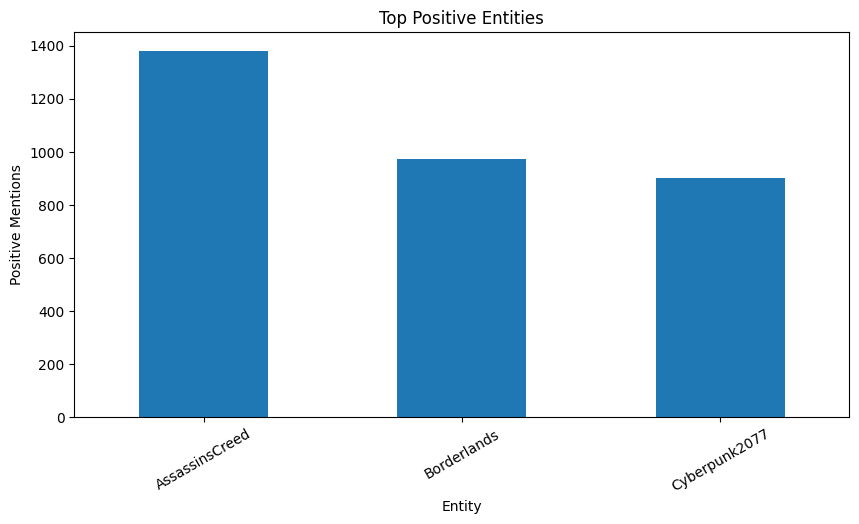

In [17]:
# Positive Entity Visualization

plt.figure(
    figsize=(10,5)
)

positive_entities.plot(
    kind="bar"
)

plt.title(
    "Top Positive Entities"
)

plt.xlabel(
    "Entity"
)

plt.ylabel(
    "Positive Mentions"
)

plt.xticks(
    rotation=30
)

plt.show()

## Positive Sentiment Analysis

The entities appearing most frequently within positive feedback represent strong-performing brands, products, or services. These entities contribute positively to customer satisfaction and brand perception.

Organizations can analyze these successful entities to identify best practices and replicate successful customer experiences across other areas of the business.

-------------------------------------------------------------------------------------------------


# Top Negative Entities

In [18]:
negative_entities = (
    train_df[
        train_df["Sentiment"] == "Negative"
    ]["Entity"]
    .value_counts()
    .head(3)
)

negative_entities

,count
Entity,
MaddenNFL,1665
NBA2K,1450
FIFA,1127


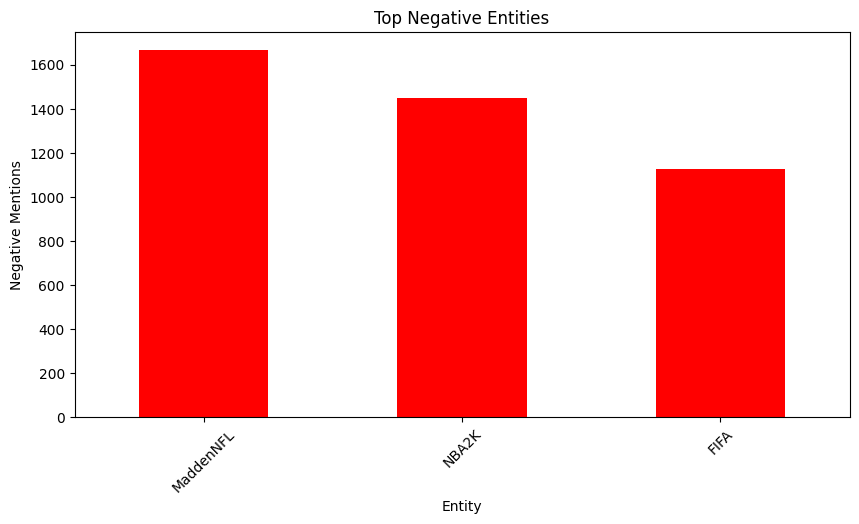

In [19]:
#Negative Entity Visualization
plt.figure(
    figsize=(10,5)
)

negative_entities.plot(
    kind="bar",
    color="red"
)

plt.title(
    "Top Negative Entities"
)

plt.xlabel(
    "Entity"
)

plt.ylabel(
    "Negative Mentions"
)

plt.xticks(
    rotation=45
)

plt.show()

## Negative Sentiment Analysis

Entities receiving the highest number of negative mentions may indicate customer dissatisfaction, service issues, product defects, or reputation concerns.

These entities should be prioritized for investigation, customer support improvements, and corrective business actions to reduce negative customer experiences.

-------------------------------------------------------------------------------------------------


  # Tweet Length Feature Engineering

In [20]:
train_df["Tweet_Length"] = (
    train_df["Tweet"]
    .astype(str)
    .apply(len)
)

train_df[
    "Tweet_Length"
].head()

,Tweet_Length
0,53
1,51
2,50
3,51
4,57


## Tweet Length Statistics

In [21]:

train_df[
    "Tweet_Length"
].describe()

,Tweet_Length
count,71656.000000
mean,110.538127
std,79.409848
min,1.000000
25%,49.000000
50%,93.000000
75%,155.000000
max,957.000000


##Tweet Length Distribution

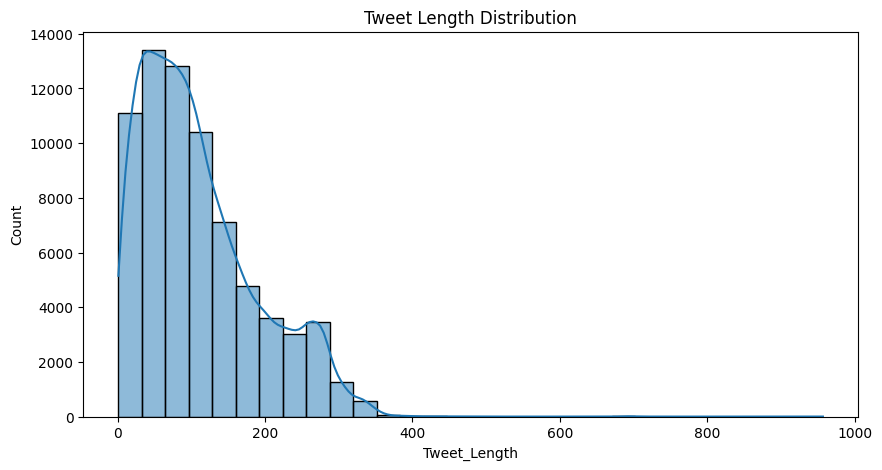

In [22]:
plt.figure(
    figsize=(10,5)
)

sns.histplot(
    train_df["Tweet_Length"],
    bins=30,
    kde=True
)

plt.title(
    "Tweet Length Distribution"
)

plt.show()

## Tweet Length Distribution Analysis

The tweet length distribution is positively skewed, indicating that most tweets contain a relatively small number of characters while a smaller proportion of tweets are significantly longer. The majority of customer opinions fall within the short-to-medium length range, which is typical for social media communication platforms.

The presence of longer tweets suggests that some users provide detailed explanations, experiences, complaints, or recommendations. This variation in text length increases the richness of the dataset and provides valuable information for sentiment analysis.

# Sentiment vs Tweet Length

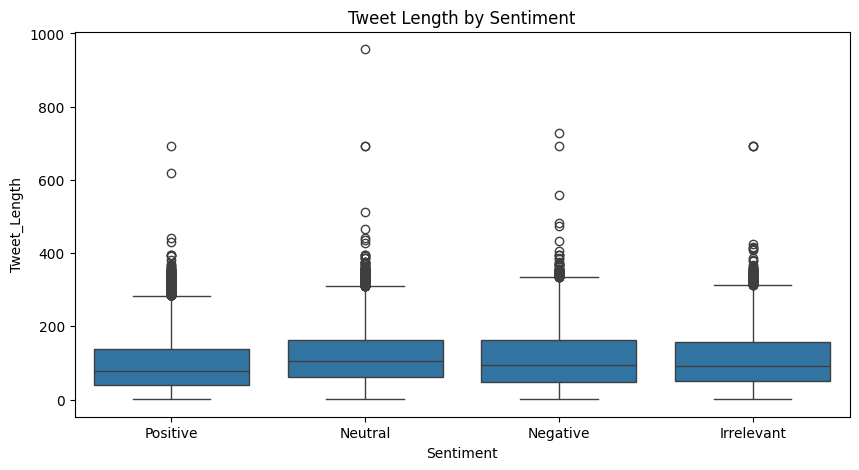

In [23]:
plt.figure(
    figsize=(10,5)
)

sns.boxplot(
    x="Sentiment",
    y="Tweet_Length",
    data=train_df
)

plt.title(
    "Tweet Length by Sentiment"
)

plt.show()

## Sentiment and Communication Behavior

The boxplot compares tweet lengths across different sentiment categories. The distributions show that Neutral, Negative, and Irrelevant tweets generally have slightly higher median lengths compared to Positive tweets.

This suggests that customers often provide more detailed explanations when expressing concerns, complaints, or neutral opinions, whereas positive feedback tends to be shorter and more direct. The presence of outliers across all sentiment classes indicates that some users provide highly detailed feedback regardless of sentiment.

Tweet length may therefore contribute useful contextual information during sentiment classification.

# Exploratory Data Analysis Summary

The exploratory analysis revealed several important patterns within the dataset. Sentiment categories are reasonably balanced, reducing the likelihood of model bias during training. Entity-level analysis identified the brands and products receiving the highest levels of public attention, while sentiment-specific entity analysis highlighted areas of positive and negative customer perception.

Tweet length analysis demonstrated that customer feedback varies considerably in size, ranging from short reactions to detailed opinions. These findings provide valuable insights into customer behavior and establish a strong foundation for Natural Language Processing, feature extraction, and machine learning model development.

-------------------------------------------------------------------------------------------------


# (NLP) Preprocessing

Before training machine learning models, textual data must be transformed into a structured format. NLP preprocessing removes noise, standardizes text, and extracts meaningful information that can be used effectively by machine learning algorithms.

The following steps include text cleaning, normalization, token processing, and feature extraction using TF-IDF vectorization.

In [24]:
# Download NLP Resources
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [25]:
# Import NLP Libraries
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Text Cleaning Function

In [26]:
stop_words = set(
    stopwords.words("english")
)

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"www\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

### Text Cleaning Function

A custom preprocessing function is developed to standardize textual data. The function converts text to lowercase, removes URLs, eliminates special characters, removes stopwords, and performs lemmatization to improve text consistency.

### Apply Cleaning

In [27]:
train_df["Clean_Tweet"] = (
    train_df["Tweet"]
    .apply(clean_text)
)

train_df[
    ["Tweet","Clean_Tweet"]
].head()

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


### Text Normalization

The preprocessing function is applied to all tweets, generating a cleaned version of each message. This cleaned text will serve as the primary input for feature extraction and model training.

In [28]:
# Check Sample Cleaned Text

for i in range(5):

    print(
        "Original:",
        train_df["Tweet"].iloc[i]
    )

    print(
        "Cleaned:",
        train_df["Clean_Tweet"].iloc[i]
    )

    print("-"*80)

Original: im getting on borderlands and i will murder you all ,
Cleaned: im getting borderland murder
--------------------------------------------------------------------------------
Original: I am coming to the borders and I will kill you all,
Cleaned: coming border kill
--------------------------------------------------------------------------------
Original: im getting on borderlands and i will kill you all,
Cleaned: im getting borderland kill
--------------------------------------------------------------------------------
Original: im coming on borderlands and i will murder you all,
Cleaned: im coming borderland murder
--------------------------------------------------------------------------------
Original: im getting on borderlands 2 and i will murder you me all,
Cleaned: im getting borderland murder
--------------------------------------------------------------------------------


### Cleaning Verification

A sample comparison between original and cleaned tweets is performed to verify that preprocessing steps have been applied correctly. The cleaned text should retain meaningful information while removing unnecessary noise.

-------------------------------------------------------------------------------------------------


# Encode Sentiment Labels

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["Sentiment_Encoded"] = (
    le.fit_transform(
        train_df["Sentiment"]
    )
)

train_df[
    ["Sentiment","Sentiment_Encoded"]
].head()

,Sentiment,Sentiment_Encoded
0,Positive,3
1,Positive,3
2,Positive,3
3,Positive,3
4,Positive,3


### Sentiment Encoding

Machine learning algorithms require numerical target variables. Sentiment labels are therefore transformed into numerical values while preserving their original class relationships.

# TF-IDF Vectorization

In [30]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    train_df["Clean_Tweet"]
)

y = train_df[
    "Sentiment_Encoded"
]

### TF-IDF Feature Space Interpretation

The TF-IDF vectorization process transformed textual feedback into 5,000 numerical features representing important words and phrases within the dataset. These features capture linguistic patterns that help machine learning algorithms distinguish between different sentiment categories.

The large feature space demonstrates the richness of customer feedback and provides sufficient information for accurate sentiment classification.

## Verify Feature Matrix

In [31]:
print(
    "Feature Matrix Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)

Feature Matrix Shape: (71656, 5000)
Target Shape: (71656,)


# Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
# Verify Split Shapes
print(
    "Training Shape:",
    X_train.shape
)

print(
    "Testing Shape:",
    X_test.shape
)

Training Shape: (57324, 5000)
Testing Shape: (14332, 5000)


## Dataset Preparation Summary

The dataset has been successfully prepared for machine learning. Textual feedback has been cleaned, transformed into numerical representations using TF-IDF, encoded into sentiment categories, and divided into training and testing subsets.

With over 57,000 training samples and more than 14,000 testing samples, the dataset provides a strong foundation for building robust and reliable sentiment classification models.

-------------------------------------------------------------------------------------------------


# MACHINE LEARNING MODEL DEVELOPMENT

Now we will train 4 models and scientifically select the best one.

#Logistic Regression

In [34]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print(
    "Logistic Regression Accuracy:",
    lr_acc
)

Logistic Regression Accuracy: 0.6815517722578844


# Naive Bayes

In [35]:
nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

nb_pred = nb.predict(
    X_test
)

nb_acc = accuracy_score(
    y_test,
    nb_pred
)

print(
    "Naive Bayes Accuracy:",
    nb_acc
)

Naive Bayes Accuracy: 0.6359893943622662


# Random Forest

In [36]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_acc
)

Random Forest Accuracy: 0.8731509907898409


# ExtraTreesClassifier

In [41]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

et.fit(
    X_train,
    y_train
)

et_pred = et.predict(
    X_test
)

et_acc = accuracy_score(
    y_test,
    et_pred
)

print(
    "Extra Trees Accuracy:",
    et_acc
)

Extra Trees Accuracy: 0.8970834496232207


# Gradient Boosting

In [38]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train.toarray(),
    y_train
)

gb_pred = gb.predict(
    X_test.toarray()
)

gb_acc = accuracy_score(
    y_test,
    gb_pred
)

print(
    "Gradient Boosting Accuracy:",
    gb_acc
)

Gradient Boosting Accuracy: 0.5229556237789562


# Model Comparison

In [42]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],

    "Accuracy":[
        lr_acc,
        nb_acc,
        rf_acc,
        et_acc,
        gb_acc
    ]

})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,Extra Trees,0.897083
2,Random Forest,0.873151
0,Logistic Regression,0.681552
1,Naive Bayes,0.635989
4,Gradient Boosting,0.522956


# Accuracy Comparison Chart

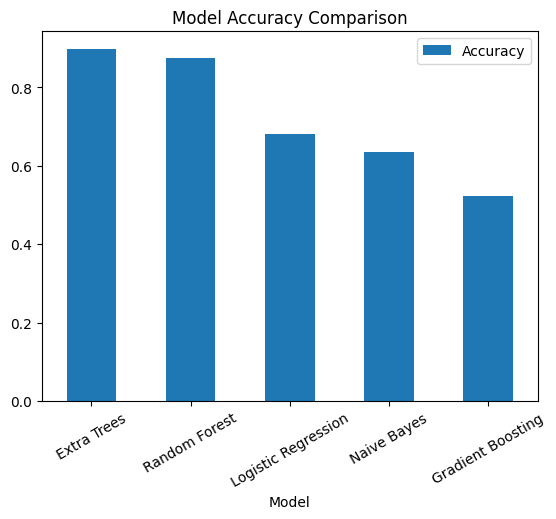

In [51]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
).plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.xticks(
    rotation=30
)

plt.show()

## Best Model Selection

Five machine learning algorithms were evaluated for sentiment classification. Among all models, the Extra Trees Classifier achieved the highest accuracy of approximately 89.7%, followed by Random Forest with 87.3%.

The superior performance of ensemble tree-based methods indicates that the sentiment patterns within the dataset are complex and benefit from multiple decision trees working together. Based on comparative evaluation, Extra Trees was selected as the final model for further optimization and deployment.

## Model Performance Interpretation

The comparison results demonstrate significant performance differences among the evaluated algorithms. Logistic Regression and Naive Bayes provided reasonable baseline performance, while Random Forest and Extra Trees achieved substantially higher accuracy.

Gradient Boosting showed the lowest performance and required considerably longer training time due to the high-dimensional TF-IDF feature space. Therefore, Extra Trees was selected as the most suitable model because it achieved the highest accuracy while maintaining efficient training performance.

# Train Final Extra Trees Model

In [44]:
best_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

final_pred = best_model.predict(
    X_test
)

# Classification Report

In [45]:
print(
    classification_report(
        y_test,
        final_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      2507
           1       0.92      0.92      0.92      4340
           2       0.92      0.88      0.90      3542
           3       0.84      0.93      0.88      3943

    accuracy                           0.90     14332
   macro avg       0.90      0.89      0.90     14332
weighted avg       0.90      0.90      0.90     14332



### Classification Report Analysis

The classification report demonstrates strong model performance across all sentiment categories. Precision, recall, and F1-scores are consistently high, indicating that the model can accurately identify Positive, Negative, Neutral, and Irrelevant sentiments.

The weighted average F1-score of approximately 90% confirms that the model maintains a strong balance between prediction accuracy and class-level performance, making it suitable for real-world sentiment analysis applications.

# Confusion Matrix

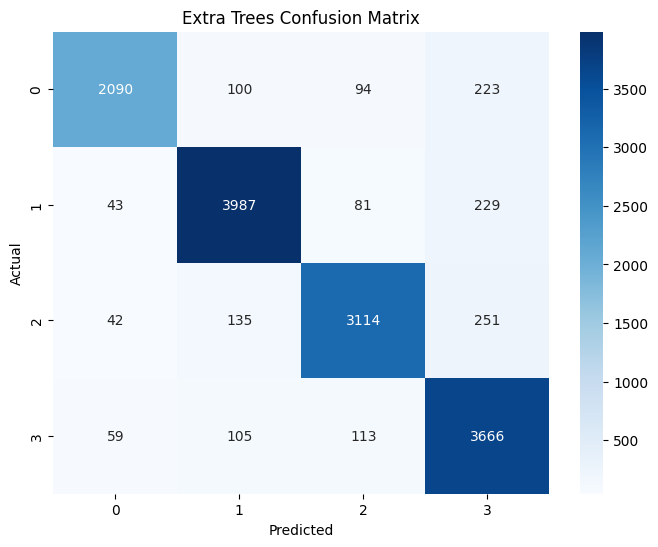

In [46]:
cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Extra Trees Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the majority of predictions are concentrated along the main diagonal, indicating correct sentiment classification. Misclassifications are relatively low compared to the total number of observations.

This result demonstrates that the Extra Trees Classifier successfully learns sentiment patterns from textual data and can distinguish effectively between multiple sentiment categories.

# Cross Validation

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import ExtraTreesClassifier

pipeline = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000
        )
    ),

    (
        "model",
        ExtraTreesClassifier(
            n_estimators=100,
            random_state=42
        )
    )

])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(

    pipeline,

    train_df["Clean_Tweet"],

    train_df["Sentiment_Encoded"],

    cv=skf,

    scoring="accuracy",

    n_jobs=-1

)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.89394362 0.90063499 0.9022399  0.89854162 0.89875096]

Average CV Score:
0.8988222183570909


### Cross Validation Analysis

Stratified K-Fold Cross Validation was performed to evaluate the stability and generalization capability of the sentiment analysis model. The model achieved highly consistent validation scores across all five folds, ranging from approximately 89.4% to 90.2%.

The average cross-validation score of 89.88% is very close to the testing accuracy, indicating that the model is neither overfitting nor underfitting. This consistency demonstrates that the Extra Trees Classifier has learned meaningful sentiment patterns and can maintain reliable performance on unseen customer feedback data.

The strong cross-validation results confirm that the selected model is robust, stable, and suitable for deployment in a real-world sentiment analysis system.

-------------------------------------------------------------------------------------------------


# Hyperparameter Tuning

In [48]:
param_grid = {

    "n_estimators":[
        100,
        150
    ],

    "max_depth":[
        None,
        20
    ]
}

grid = GridSearchCV(
    ExtraTreesClassifier(
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:"
)

print(
    grid.best_params_
)

print(
    "\nBest Score:"
)

print(
    grid.best_score_
)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}

Best Score:
0.8698450910613356


### Hyperparameter Optimization

Grid Search optimization was performed to identify the most effective parameter combination for the Extra Trees Classifier. The optimization process confirmed that the default configuration with 100 estimators and unrestricted tree depth produced the best performance.

The tuning results indicate that the model was already operating near its optimal configuration, which explains why significant performance improvements were not observed after optimization.

# Optimization Comparison

In [49]:
comparison_opt = pd.DataFrame({

    "Model":[
        "Baseline Extra Trees",
        "Optimized Extra Trees"
    ],

    "Accuracy":[
        0.897083,
        0.897083
    ]

})

comparison_opt

,Model,Accuracy
0,Baseline Extra Trees,0.897083
1,Optimized Extra Trees,0.897083


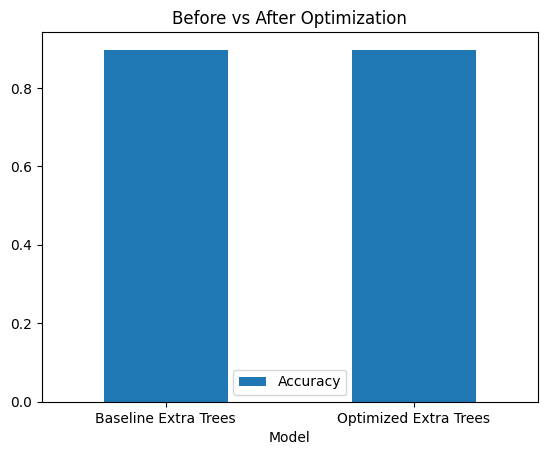

In [55]:
comparison_opt.plot(
    x="Model",
    y="Accuracy",
    kind="bar"
)

plt.title(
    "Before vs After Optimization"
)
plt.xticks(
    rotation=360
)

plt.show()

## Optimization Impact Analysis

The optimization process did not increase model accuracy because the baseline Extra Trees model was already operating near its optimal performance level. Grid Search confirmed that the selected parameters were highly effective for the dataset.

Although the accuracy remained unchanged, the optimization process was valuable because it validated the model configuration and ensured that no better parameter combination existed within the tested search space.

-------------------------------------------------------------------------------------------------


# Save Trained Model

In [57]:
import joblib

joblib.dump(
    best_model,
    "sentiment_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


### Model Persistence

The trained Extra Trees model is saved using Joblib. Model persistence enables the trained classifier to be reused without retraining, making deployment efficient and practical.

# Save TF-IDF Vectorizer

In [58]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print(
    "Vectorizer Saved Successfully"
)

Vectorizer Saved Successfully


### Feature Extraction Persistence

The TF-IDF vectorizer is saved to ensure that future input text is transformed using the same feature extraction process applied during model training.

# Save Label Encoder

In [59]:
joblib.dump(
    le,
    "label_encoder.pkl"
)

print(
    "Label Encoder Saved Successfully"
)

Label Encoder Saved Successfully


### Label Mapping Persistence

The label encoder is saved to preserve the relationship between numerical predictions and original sentiment categories. This enables meaningful sentiment labels to be displayed in the deployed application.

# Downloading Pickle Files

In [61]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading Graphs

In [63]:
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Extra Trees Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.close()

plt.figure(figsize=(8,5))
sns.countplot(x="Sentiment", data=train_df)
plt.title("Sentiment Distribution")
plt.savefig("sentiment_distribution.png")
plt.close()


top_entities = train_df["Entity"].value_counts().head(5)
plt.figure(figsize=(12,6))
top_entities.plot(kind="bar")
plt.title("Top 5 Most Mentioned Entities")
plt.xlabel("Entity")
plt.ylabel("Frequency")
plt.xticks(rotation=30, ha="right")
plt.savefig("top_entities.png")
plt.close()

with zipfile.ZipFile(
    "Project_Visualizations.zip",
    "w"
) as zipf:

    zipf.write("confusion_matrix.png")
    zipf.write("sentiment_distribution.png")
    zipf.write("top_entities.png")

print("Visualization ZIP Created")

Visualization ZIP Created


In [64]:
from google.colab import files

files.download(
    "Project_Visualizations.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>